This requires the following packages (named from pip)
- pyserial
- opencv-python
- matplotlib
- numpy

In [261]:
import serial
import cv2 as cv
from matplotlib import pyplot as plt
import time
import numpy as np
import threading

# Sobel Filtering on an FPGA
This section applies a sobel filter of the user selected images with the FPGA. 

## Preprocessing
First, load the image. The image can be the lab provided picture of a car, or a custom hand picked image. Comment out `image_path` to choose

(480, 640, 3)


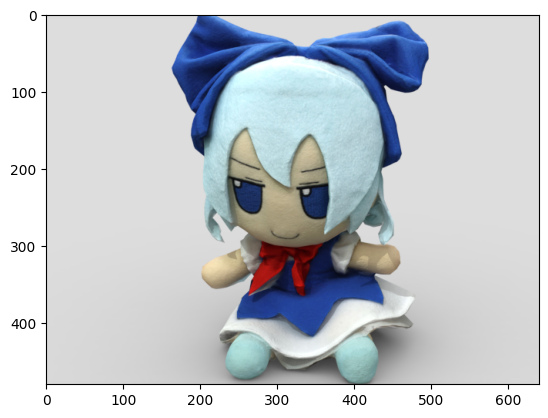

In [262]:
# Load the image
# img_path = "car.jpg"
img_path = "fumo.png"
cv_img = cv.imread(img_path, cv.IMREAD_COLOR)
print(cv_img.shape)

# Check if image is loaded
assert cv_img is not None, 'Error opening image.'

# You can ignore the whole cvtColor here. This is just to handle OpenCV/Matplotlib weirdness.
plt.imshow(cv.cvtColor(cv_img, cv.COLOR_BGR2RGB))

rgb_image = cv.cvtColor(cv_img, cv.COLOR_BGR2RGB)

In [263]:
buf_clear = np.zeros(640*3*3, dtype=np.uint8)

img_inp_sz = rgb_image.flatten().shape[0]
img_out_sz = int(rgb_image.flatten().shape[0] / 3)

# add some extra bytes to clear registers and memory
fpga_in = buf_clear.tobytes() + rgb_image.flatten().tobytes()

fpga_inp_sz = len(fpga_in)

# outputs h & v values 640*480 times
fpga_out_sz = int((fpga_inp_sz / 3)) * 2

print(f"inp_sz: {fpga_inp_sz}, out_sz: {fpga_out_sz}")

inp_sz: 927360, out_sz: 618240


## Send to FPGA

In [264]:
ser = serial.Serial('/dev/cu.usbserial-ib6dSpnd1', 115200, timeout=None, parity=serial.PARITY_NONE, stopbits=serial.STOPBITS_ONE,  bytesize=serial.EIGHTBITS)
ser.reset_input_buffer()
ser.reset_output_buffer()

In [265]:
# function to read TX from FPGA, intended to be ran in a separate thread
def ser_read(ser, expected_sz, res):
    fpga_out = b''
    start_time = time.perf_counter()
    for i in range(int(expected_sz)):
        fpga_out += ser.read(1)
    end_time = time.perf_counter()
    
    execution_time = end_time - start_time
    print(f"Finished reading in: {execution_time:.6f} seconds")
    res += [fpga_out]

In [266]:
# now we shall filter!

t_reader_res = []
reader = threading.Thread(target=ser_read, args=(ser, fpga_out_sz, t_reader_res))
reader.start()

start_time = time.perf_counter()
ser.write(fpga_in)
ser.flush()
end_time = time.perf_counter()

execution_time = end_time - start_time
print(f"Finish writing in: {execution_time:.6f} seconds")

reader.join(timeout=100)

if reader.is_alive():
    print("Error: Reader thread timed out!")
else:
    # Retrieve data from the container
    fpga_out = t_reader_res[0]
    print(f"Sent {img_inp_sz} bytes, Received {len(fpga_out)} bytes.")

Finish writing in: 79.609433 seconds
Finished reading in: 80.479556 seconds
Sent 921600 bytes, Received 618240 bytes.


## Post-processing

In [267]:
# strip out the zeroing inputs
print(len(fpga_out))
np_fpga_out = np.frombuffer(fpga_out, dtype=np.uint8)

noclear_buf = np_fpga_out[640*3*2:]

H = noclear_buf[0::2].reshape(480,640)
V = noclear_buf[1::2].reshape(480,640)
# print(S.shape)
# print(H.shape)

# np_fpga_out[0::2][int(buf_clear.shape[0]/3):]
# no_bufclear.reshape((480, 640))[0:]

hue = H
# print(hue)
print(hue.shape)
val = V
print(val.max())
sat = np.ones(H.shape, dtype=np.uint8) * 255

618240
(480, 640)
250


True

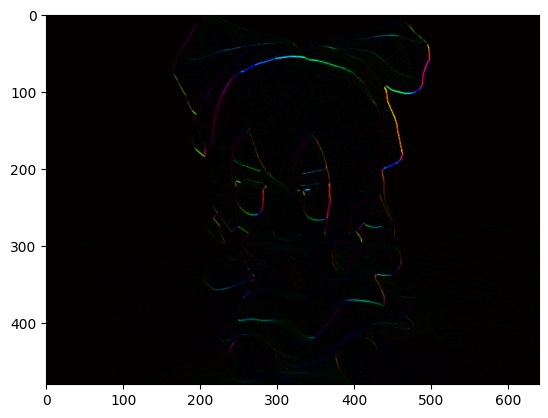

In [268]:
hsv = np.dstack((hue, sat, val))
rgb = cv.cvtColor(hsv, cv.COLOR_HSV2RGB)
plt.imshow(rgb)

bgr = cv.cvtColor(hsv, cv.COLOR_HSV2BGR)
cv.imwrite('sobel_hsv_fpga2.jpg', bgr)